In [75]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score


pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\adams\AppData\Local\Temp\ipykernel_65504\296405123.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [76]:
samples_df, cns_df = cdu.main_load("3MB")
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
subs_df = pd.concat([cns.select_cns_by_type(cns_df, samples_df, "LUAD"), cns.select_cns_by_type(cns_df, samples_df, "LUSC")])
# subs_df = cns.cns_head(cns_df, 400)

In [77]:
def calc_distances(cns_df, column):
	"""
	Calculate the pairwise distance matrix between samples for the given column.
	Each sample is represented by the vector of values for the specified column.
	"""
	# Pivot the dataframe to get samples as rows and regions as columns
	pivot = cns_df.pivot(index='sample_id', columns='name', values=column).fillna(0)
	sample_ids = pivot.index
	values = pivot.values
	# divide by the sum of each row to get proportions
	values = values / values.sum(axis=1, keepdims=True)

	# Calculate pairwise L1 (Manhattan) distances
	n = len(sample_ids)
	dist = np.zeros((n, n))
	for i in range(n):
		for j in range(n):
			dist[i, j] = np.abs(values[i] - values[j]).sum()
	# Return as a DataFrame for easier downstream use
	return pd.DataFrame(dist, index=sample_ids, columns=sample_ids)

In [78]:
start = time.time()
dist_matrix = calc_distances(subs_df, "total_cn")
print(f"Elapsed time: {time.time() - start:.2f} seconds")
dist_matrix.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_wass_dist_2.tsv"), sep="\t", index=True, header=True)

Elapsed time: 37.91 seconds


In [79]:
# Get sample metadata (assuming samples_df has metadata we can use)
sample_metadata = samples_df.loc[dist_matrix.index]

# Perform MDS on the distance matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
positions = mds.fit_transform(dist_matrix.values)

# Create a DataFrame with MDS results
mds_df = pd.DataFrame(positions, columns=['MDS1', 'MDS2'], index=dist_matrix.index)

# Merge with metadata (adjust this based on your actual metadata structure)
# If you have a 'type' or 'subtype' column that would be useful for coloring
if 'type' in sample_metadata.columns:  # Adjust column name as needed
    mds_df['type'] = sample_metadata['type']

In [83]:
labels = mds_df['type'].values
unique_labels = np.unique(labels)
dist_vals = dist_matrix.values

# Build boolean masks for each group
mask_own = labels[:, None] == labels[None, :]
mask_other = labels[:, None] != labels[None, :]


# Exclude self in own group distances
np.fill_diagonal(mask_own, False)

# Compute average distances
avg_dist_own = (dist_vals * mask_own).sum(axis=1) / mask_own.sum(axis=1)
avg_dist_other = (dist_vals * mask_other).sum(axis=1) / mask_other.sum(axis=1)

# Assemble results
avg_dist_df = pd.DataFrame({
    'sample_id': dist_matrix.index,
    'type': labels,
    'avg_dist_own': avg_dist_own,
    'avg_dist_other': avg_dist_other
})

avg_dist_df["diff"] = avg_dist_df["avg_dist_other"] - avg_dist_df["avg_dist_own"]
avg_dist_df.sort_values("diff", ascending=True, inplace=True)
avg_dist_df


,sample_id,type,avg_dist_own,avg_dist_other,diff
984,CRUK0584_SU_T1-R2,LUSC,0.321622,0.262426,-0.059196
531,CRUK0334_SU_T1-R2,LUSC,0.362039,0.305683,-0.056356
530,CRUK0334_SU_T1-R1,LUSC,0.337677,0.281430,-0.056247
1879,TCGA-63-A5MG,LUSC,0.298595,0.243021,-0.055574
2105,TCGA-85-A513,LUSC,0.305110,0.249768,-0.055343
...,...,...,...,...,...
928,CRUK0548_SU_T1-R2,LUAD,0.301528,0.376536,0.075008
1314,CRUK0881_SU_T1-R2,LUAD,0.285885,0.361095,0.075210
1526,TCGA-35-3615,LUAD,0.262597,0.338313,0.075716
1316,CRUK0881_SU_T1-R4,LUAD,0.279268,0.356459,0.077190


In [116]:
# Only calculate silhouette score if there are at least 2 clusters
labels = mds_df['type'].values
sil_score = silhouette_score(mds_df[['MDS1', 'MDS2']].values, labels)
print(f"Silhouette score (using sample type as clusters): {sil_score:.3f}")

Silhouette score (using sample type as clusters): 0.311


In [ ]:
std = avg_dist_df["diff"].std()
outliers_df = avg_dist_df[avg_dist_df["diff"] < -std]
outliers_df.head(10)

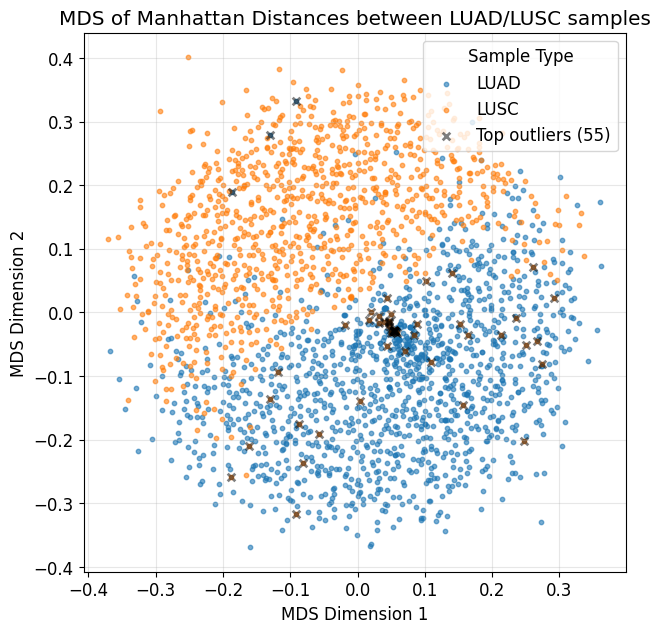

In [113]:
# Plot MDS results
plt.figure(figsize=(7, 7))

# If type information is available, use it for coloring
types = mds_df['type'].unique()
for i, t in enumerate(types):
	mask = mds_df['type'] == t
	plt.scatter(mds_df.loc[mask, 'MDS1'], mds_df.loc[mask, 'MDS2'], 
				label=t, color=color_map[i % len(color_map)], s=10, alpha=0.6)

plt.scatter(mds_df.loc[outliers_df['sample_id'], 'MDS1'],
			mds_df.loc[outliers_df['sample_id'], 'MDS2'],
			marker='x', color='black', s=30, alpha=.5, linewidths=2, label=f'Top outliers ({len(outliers_df)})')

plt.legend(title='Sample Type')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS of Manhattan Distances between LUAD/LUSC samples')
plt.grid(alpha=0.3)

# Optionally save the MDS results
mds_df.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_mds_positions.tsv"), sep="\t", index=True)
cdu.save_cns_fig("LUAD_LUSC_mds_positions")

In [100]:
lusc_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUSC'"))
luad_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUAD'"))
lusc_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUSC'").set_index("sample_id"))
luad_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUAD'").set_index("sample_id"))

lusc_group = cns.group_samples(lusc_df, group_name="LUSC all")
luad_group = cns.group_samples(luad_df,group_name="LUAD all")
lusc_outliers_group = cns.group_samples(lusc_outliers_df, group_name="LUSC outliers")
luad_outliers_group = cns.group_samples(luad_outliers_df, group_name="LUAD outliers")

all_groups = pd.concat([lusc_group, luad_group, lusc_outliers_group, luad_outliers_group])


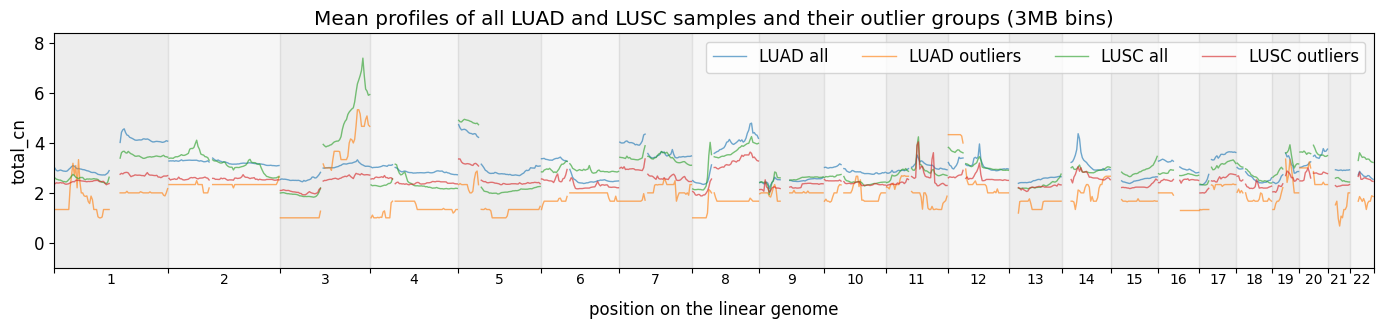

In [115]:
fig, axs = cns.fig_lines(all_groups, cn_columns="total_cn", colors=color_map[:4])
fig.set_size_inches(14, 3)
axs.legend(loc="upper right", ncol=4)
plt.title("Mean profiles of all LUAD and LUSC samples and their outlier groups (3MB bins)")
cdu.save_cns_fig("LUAD_LUSC_outliers")